In [2]:
import base64
import re
import io
from PIL import Image
import matplotlib.pyplot as plt

# Test Image Process, LLM Evaluation

In [3]:

# Your functions
def base64_to_image(base64_str):
    match = re.match(r'^data:image/(?P<fmt>\w+);base64,', base64_str)
    if not match:
        raise ValueError("Unsupported base64 image format")
    
    img_format = match.group("fmt").upper()
    base64_data = re.sub('^data:image/.+;base64,', '', base64_str)
    byte_data = base64.b64decode(base64_data)
    image_data = io.BytesIO(byte_data)
    img = Image.open(image_data)

    return img, img_format


def image_to_base64(img, img_format="JPEG"):
    buffer = io.BytesIO()
    
    # Pillow uses "JPEG", not "JPG"
    if img_format == "JPG":
        img_format = "JPEG"

    img.save(buffer, format=img_format)
    base64_str = base64.b64encode(buffer.getvalue()).decode()
    return f"data:image/{img_format.lower()};base64,{base64_str}"

def process_upload_img(contents: str, b_crop_to_512: bool = False):
    img, img_format = base64_to_image(contents)

    if b_crop_to_512:
        # Crop to center square
        width, height = img.size
        min_dim = min(width, height)
        left = (width - min_dim) // 2
        top = (height - min_dim) // 2
        right = left + min_dim
        bottom = top + min_dim
        img_cropped = img.crop((left, top, right, bottom))
        img_resized = img_cropped.resize((512, 512), Image.LANCZOS)
    else:
        # Resize with aspect ratio preserved, long side = 512
        width, height = img.size
        if width >= height:
            new_width = 512
            new_height = int(height * 512 / width)
        else:
            new_height = 512
            new_width = int(width * 512 / height)
        img_resized = img.resize((new_width, new_height), Image.LANCZOS)

    base64_resized_str = image_to_base64(img_resized, img_format)

    return img_resized, base64_resized_str


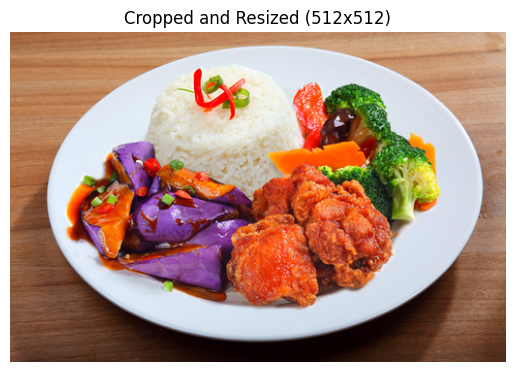

Processed image saved as output_512.jpg
Base64 output length: 42623


In [4]:

# Test image path
input_path = r"E:\Projects\Selfwork\FoodLens\app\data\mixed_rice.jpg" # Use your own test image path

# Step 1: Open and encode test image to base64 with data URI prefix
with open(input_path, "rb") as image_file:
    base64_encoded = base64.b64encode(image_file.read()).decode()
    contents = f"data:image/jpeg;base64,{base64_encoded}"

# Step 2: Run test
img_processed, base64_out = process_upload_img(contents)

# Step 3: Display result using matplotlib
plt.imshow(img_processed)
plt.title("Cropped and Resized (512x512)")
plt.axis("off")
plt.show()

# Step 4: Optional: Save output
img_processed.save("output_512.jpg")
print("Processed image saved as output_512.jpg")

# Step 5: Sanity check base64 output
assert base64_out.startswith("/9j") or base64_out.startswith("data:image"), "Base64 output looks invalid"
print("Base64 output length:", len(base64_out))


In [5]:
from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI
import pandas as pd

model = ChatOpenAI(model="gpt-4o-mini")

In [6]:
prompt_template = '''
You are a food nutrition expert.

Analyze the uploaded food image and provide the following:

1. Identify each visible food item in the image.
2. Estimate the portion size of each item (e.g., 1 cup, 150g, 1 slice).
3. For each item, estimate the following:
   - Calories (kcal)
   - Protein (g)
   - Total Fat (g)
   - Saturated Fat (g)
   - Carbohydrates (g)

4. At the end, provide a total summary for the entire meal across all items.
5. If any food items or portions are ambiguous, state your assumptions clearly.

Assume the photo represents a single-person meal and make reasonable estimations based on visual cues and typical serving sizes.
'''

message = HumanMessage(
    content=[
        {"type": "text", "text": prompt_template},
        {
            "type": "image_url",
            "image_url": {"url": f"{base64_out}"},
        },
    ],
)
# response = model.invoke([message], max_tokens=1000)
# print(response.content)

In [7]:
from typing import List
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI

# Step 1: Define structured output model
class FoodItem(BaseModel):
    food_item: str = Field(..., description="Name of the identified food")
    portion: str = Field(..., description="Estimated portion size, e.g., 1 cup, 150g")
    calories: int = Field(..., description="Estimated calorie content")
    protein_g: float = Field(..., description="Estimated protein in grams")
    fat_g: float = Field(..., description="Estimated total fat in grams")
    saturated_fat_g: float = Field(..., description="Estimated saturated fat in grams")
    carbs_g: float = Field(..., description="Estimated carbohydrate content in grams")

class NutritionEstimate(BaseModel):
    items: List[FoodItem]
    total: FoodItem

# Step 2: Set up OpenAI LLM with structured output
llm = ChatOpenAI(
    model="gpt-4o-mini",  # or "gpt-4o-mini" if available in your org
    temperature=0,
)

llm_with_output = llm.with_structured_output(NutritionEstimate)

# Step 3: Prompt
prompt = """
You are a food nutrition expert.

Estimate the nutrition of the meal in the provided image.

1. Identify visible food items.
2. Estimate portion size for each.
3. Provide the following for each item:
   - Calories (kcal)
   - Protein (g)
   - Fat (g)
   - Saturated Fat (g)
   - Carbohydrates (g)
4. Provide a total combined nutritional summary for the entire meal.

If any assumptions are made (e.g., portion or food type), estimate them reasonably.
"""

# Step 4: Call the LLM with an image

response = llm_with_output.invoke([
    {"role": "user", "content": [
        {"type": "text", "text": prompt},
        {"type": "image_url", "image_url": {"url": base64_out}}
    ]}
])

# Step 5: Output
print(response)

df = pd.DataFrame([item.model_dump() for item in response.items])
total_row = pd.DataFrame([response.total.model_dump()])
df_with_total = pd.concat([df, total_row], ignore_index=True)


items=[FoodItem(food_item='Fried Chicken', portion='3 pieces (150g)', calories=400, protein_g=30.0, fat_g=25.0, saturated_fat_g=5.0, carbs_g=10.0), FoodItem(food_item='Steamed White Rice', portion='1 cup (150g)', calories=205, protein_g=4.0, fat_g=0.4, saturated_fat_g=0.1, carbs_g=45.0), FoodItem(food_item='Stir-Fried Vegetables (Broccoli, Carrots, Bell Peppers)', portion='1 cup (150g)', calories=70, protein_g=3.0, fat_g=0.5, saturated_fat_g=0.1, carbs_g=15.0), FoodItem(food_item='Stir-Fried Purple Eggplant', portion='1 cup (150g)', calories=120, protein_g=2.0, fat_g=7.0, saturated_fat_g=1.0, carbs_g=15.0)] total=FoodItem(food_item='Total Meal', portion='N/A', calories=895, protein_g=39.0, fat_g=33.9, saturated_fat_g=6.2, carbs_g=85.0)


In [8]:

df = pd.DataFrame([item.model_dump() for item in response.items])
total_row = pd.DataFrame([response.total.model_dump()])
df_with_total = pd.concat([df, total_row], ignore_index=True)

In [10]:
df_with_total.columns

Index(['food_item', 'portion', 'calories', 'protein_g', 'fat_g',
       'saturated_fat_g', 'carbs_g'],
      dtype='object')

In [11]:
column_mapping = {'food_item': 'Food Item', 'portion': 'Portion', 'calories': 'Calories',
                  'protein_g': 'Protein(g)', 'fat_g': 'Fat(g)',
                  'saturated_fat_g': 'Sat. Fat(g)', 'carbs_g': 'Carbs. (g)'}

## Test AWS DB Insert or Put

In [12]:
from dotenv import load_dotenv
import boto3
from datetime import datetime

load_dotenv()

True

In [13]:
from decimal import Decimal

def convert_floats(obj):
    if isinstance(obj, float):
        return Decimal(str(obj))
    if isinstance(obj, dict):
        return {k: convert_floats(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [convert_floats(i) for i in obj]
    return obj


In [15]:
def write_record_to_dynamodb(table_name, user_id, new_records_df):
    dynamodb = boto3.resource('dynamodb')
    table = dynamodb.Table(table_name)
    
    df_ =new_records_df.copy()
    timestamp = datetime.utcnow().isoformat()
    df_['user_id'] = user_id
    df_['timestamp'] = df_.apply(lambda x: f"{timestamp}|{x['food_item']}", axis=1)
    

    with table.batch_writer() as batch:
        for item in df_.to_dict('records'):
            batch.put_item(Item=convert_floats(item))

write_record_to_dynamodb(table_name='foodlens-records-dev', user_id='test_id', new_records_df=df_with_total)

### Load Data from AWS DynamoDB

In [16]:
import boto3
import pandas as pd
from boto3.dynamodb.conditions import Key
from datetime import datetime
from decimal import Decimal

# 初始化 DynamoDB
dynamodb = boto3.resource('dynamodb')

# 工具函数：递归把 DynamoDB 的 Decimal 转成 float
def convert_decimals(obj):
    if isinstance(obj, list):
        return [convert_decimals(i) for i in obj]
    elif isinstance(obj, dict):
        return {k: convert_decimals(v) for k, v in obj.items()}
    elif isinstance(obj, Decimal):
        return float(obj)
    else:
        return obj

# 主函数：输入表名、用户 ID、时间范围，返回 DataFrame
def query_user_records_to_dataframe(table_name, user_id, start_datetime, end_datetime):
    table = dynamodb.Table(table_name)

    # 时间范围字符串，前缀匹配用
    start_prefix = start_datetime.strftime('%Y-%m-%d')
    end_prefix = end_datetime.strftime('%Y-%m-%d')

    response = table.query(
        KeyConditionExpression=Key('user_id').eq(user_id) &
                               Key('timestamp').between(start_prefix, end_prefix + '|zzz')  # 加 'zzz' 确保包含所有食物
    )

    items = response['Items']

    # 分页处理：如果有多页结果
    while 'LastEvaluatedKey' in response:
        response = table.query(
            KeyConditionExpression=Key('user_id').eq(user_id) &
                                   Key('timestamp').between(start_prefix, end_prefix + '|zzz'),
            ExclusiveStartKey=response['LastEvaluatedKey']
        )
        items.extend(response['Items'])

    # 处理 Decimal 类型
    items = convert_decimals(items)

    # 转成 DataFrame
    df = pd.DataFrame(items)

    if not df.empty:
        # 拆分 timestamp 成两列：date_time 和 food_item
        df['meal_date'] = df['timestamp'].apply(lambda x: x.split('|')[0])

        # 排序方便分析
        df = df.sort_values('meal_date')

    return df


In [17]:
from datetime import datetime, timedelta

# 查询 user123 最近 7 天记录
end_time = datetime.utcnow()
start_time = end_time - timedelta(days=7)

df = query_user_records_to_dataframe(
    table_name='foodlens-records-dev',
    user_id='User Name',
    start_datetime=start_time,
    end_datetime=end_time
)

df

,saturated_fat_g,fat_g,user_id,create_timestamp,calories,portion,food_item,timestamp,carbs_g,meal_type,protein_g,meal_date
0,5.0,25.0,User Name,2025-04-15T13:38:59.365906,400.0,3 pieces (150g),Fried Chicken,2025-04-13|133859|Fried Chicken,10.0,Dinner,30.0,2025-04-13
1,0.1,0.4,User Name,2025-04-15T13:38:59.365906,205.0,1 cup (150g),Steamed White Rice,2025-04-13|133859|Steamed White Rice,45.0,Dinner,4.0,2025-04-13
2,1.0,7.0,User Name,2025-04-15T13:38:59.365906,120.0,1 cup (150g),Stir-Fried Purple Eggplant,2025-04-13|133859|Stir-Fried Purple Eggplant,15.0,Dinner,2.0,2025-04-13
3,0.2,1.0,User Name,2025-04-15T13:38:59.365906,70.0,1 cup (150g),"Stir-Fried Vegetables (Broccoli, Carrots, Bell...",2025-04-13|133859|Stir-Fried Vegetables (Brocc...,15.0,Dinner,3.0,2025-04-13
4,6.3,33.4,User Name,2025-04-15T13:38:59.365906,895.0,N/A,Total Meal,2025-04-13|133859|Total Meal,85.0,Dinner,39.0,2025-04-13
5,5.0,25.0,User Name,2025-04-15T13:38:53.716109,400.0,3 pieces (150g),Fried Chicken,2025-04-14|133853|Fried Chicken,10.0,Lunch,30.0,2025-04-14
6,0.1,0.4,User Name,2025-04-15T13:38:53.716109,205.0,1 cup (150g),Steamed White Rice,2025-04-14|133853|Steamed White Rice,45.0,Lunch,4.0,2025-04-14
7,1.0,7.0,User Name,2025-04-15T13:38:53.716109,120.0,1 cup (150g),Stir-Fried Purple Eggplant,2025-04-14|133853|Stir-Fried Purple Eggplant,15.0,Lunch,2.0,2025-04-14
8,0.2,1.0,User Name,2025-04-15T13:38:53.716109,70.0,1 cup (150g),"Stir-Fried Vegetables (Broccoli, Carrots, Bell...",2025-04-14|133853|Stir-Fried Vegetables (Brocc...,15.0,Lunch,3.0,2025-04-14
9,6.3,33.4,User Name,2025-04-15T13:38:53.716109,895.0,N/A,Total Meal,2025-04-14|133853|Total Meal,85.0,Lunch,39.0,2025-04-14


In [ ]:
## Plot 1: Bar chart: 
#   Input: Today | user_id
#   Output: Bar plot, and if the user information provided, then can calculate corresponding threshold

## Plot 2: Line chart: 
#   Input: Last xx days/month | user_id
#   Output: X axis as time, and Y axis as Different nutritions for each plot

### Plot 1: Bar chart

In [49]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [97]:
end_time = datetime.utcnow()
start_time = end_time

df_today = query_user_records_to_dataframe(
    table_name='foodlens-records-dev',
    user_id='User Name',
    start_datetime=start_time,
    end_datetime=end_time
)

df_today

,saturated_fat_g,fat_g,user_id,create_timestamp,calories,portion,food_item,timestamp,carbs_g,meal_type,protein_g,meal_date
0,1.5,2.0,User Name,2025-04-18T10:30:59.186953,60.0,1 tablespoon (20g),Condensed milk,2025-04-18|103059|Condensed milk,10.0,Breakfast,1.0,2025-04-18
14,0.0,0.0,User Name,2025-04-18T10:38:48.668151,56.0,1 tablespoon (20g),Jam (1 tablespoon),2025-04-18|103845|Jam (1 tablespoon),15.0,Snack,0.0,2025-04-18
13,5.0,8.0,User Name,2025-04-18T10:38:48.668151,72.0,1 pat (10g),Butter (1 pat),2025-04-18|103845|Butter (1 pat),0.0,Snack,0.1,2025-04-18
12,5.5,10.0,User Name,2025-04-18T10:36:28.935169,288.0,-,Total Meal,2025-04-18|103628|Total Meal,45.0,Snack,6.1,2025-04-18
11,0.5,2.0,User Name,2025-04-18T10:36:28.935169,160.0,2 slices,Toast (2 slices),2025-04-18|103628|Toast (2 slices),30.0,Snack,6.0,2025-04-18
10,0.0,0.0,User Name,2025-04-18T10:36:28.935169,56.0,1 tablespoon (20g),Jam (1 tablespoon),2025-04-18|103628|Jam (1 tablespoon),15.0,Snack,0.0,2025-04-18
9,5.0,8.0,User Name,2025-04-18T10:36:28.935169,72.0,1 pat (10g),Butter (1 pat),2025-04-18|103628|Butter (1 pat),0.0,Snack,0.1,2025-04-18
15,0.5,2.0,User Name,2025-04-18T10:38:48.668151,160.0,2 slices,Toast (2 slices),2025-04-18|103845|Toast (2 slices),30.0,Snack,6.0,2025-04-18
8,23.5,59.0,User Name,2025-04-18T10:31:25.661731,840.0,-,Total Meal,2025-04-18|103125|Total Meal,46.0,Lunch,40.0,2025-04-18
6,3.0,10.0,User Name,2025-04-18T10:31:25.661731,140.0,2 large eggs,Fried Eggs,2025-04-18|103125|Fried Eggs,1.0,Lunch,12.0,2025-04-18


In [100]:
def get_latest_creation_records(df_raw):
    df_latest = df_raw.copy()
    df_latest['latest_rank'] = df_latest.groupby(['meal_date', 'meal_type', 'food_item'],
                                    as_index=False)['create_timestamp'].transform(lambda x: x.rank(ascending=False, method='dense'))
    df_latest = df_latest[df_latest['latest_rank']==1].copy()
    df_latest.drop(columns='latest_rank', inplace=True)
    return df_latest

df_today_latest = get_latest_creation_records(df_today)

,saturated_fat_g,fat_g,user_id,create_timestamp,calories,portion,food_item,timestamp,carbs_g,meal_type,protein_g,meal_date
0,1.5,2.0,User Name,2025-04-18T10:30:59.186953,60.0,1 tablespoon (20g),Condensed milk,2025-04-18|103059|Condensed milk,10.0,Breakfast,1.0,2025-04-18
14,0.0,0.0,User Name,2025-04-18T10:38:48.668151,56.0,1 tablespoon (20g),Jam (1 tablespoon),2025-04-18|103845|Jam (1 tablespoon),15.0,Snack,0.0,2025-04-18
13,5.0,8.0,User Name,2025-04-18T10:38:48.668151,72.0,1 pat (10g),Butter (1 pat),2025-04-18|103845|Butter (1 pat),0.0,Snack,0.1,2025-04-18
15,0.5,2.0,User Name,2025-04-18T10:38:48.668151,160.0,2 slices,Toast (2 slices),2025-04-18|103845|Toast (2 slices),30.0,Snack,6.0,2025-04-18
8,23.5,59.0,User Name,2025-04-18T10:31:25.661731,840.0,-,Total Meal,2025-04-18|103125|Total Meal,46.0,Lunch,40.0,2025-04-18
6,3.0,10.0,User Name,2025-04-18T10:31:25.661731,140.0,2 large eggs,Fried Eggs,2025-04-18|103125|Fried Eggs,1.0,Lunch,12.0,2025-04-18
5,12.0,24.0,User Name,2025-04-18T10:31:25.661731,400.0,1 croissant sandwich (about 150g),Croissant Sandwich,2025-04-18|103125|Croissant Sandwich,36.0,Lunch,12.0,2025-04-18
4,8.0,22.0,User Name,2025-04-18T10:31:25.661731,250.0,1 sausage link (about 85g),Breakfast Sausage,2025-04-18|103125|Breakfast Sausage,1.0,Lunch,14.0,2025-04-18
3,4.0,7.0,User Name,2025-04-18T10:30:59.186953,140.0,N/A,Total Meal,2025-04-18|103059|Total Meal,12.0,Breakfast,8.0,2025-04-18
2,0.0,0.0,User Name,2025-04-18T10:30:59.186953,10.0,1 tablespoon (15g),Soy sauce,2025-04-18|103059|Soy sauce,1.0,Breakfast,1.0,2025-04-18


In [102]:

# Group and prepare data
def get_plot_today_records_fig(plot_df):
    plot_df = plot_df[plot_df['food_item']!='Total Meal'].reset_index(drop=True).copy()
    df_grp = plot_df.groupby('meal_date', as_index=False)[['calories', 'carbs_g', 'protein_g', 'fat_g', 'saturated_fat_g']].sum()
    df_grp['unsaturated_fat_g'] = df_grp['fat_g'] - df_grp['saturated_fat_g']
    
    # Create subplots
    fig = make_subplots(
        rows=1, cols=2,
        column_widths=[1, 3],
        subplot_titles=['Calories', 'Nutrition']
    )
    
    # Left: Calories
    fig.add_trace(
        go.Bar(x=['calories'], y=df_grp['calories'], name='Calories', marker_color='steelblue', showlegend=False),
        row=1, col=1
    )
    
    # Right: Nutrition
    nutrients = {
        'carbs_g': 'orange',
        'protein_g': 'green',
        'saturated_fat_g': 'crimson',
        'unsaturated_fat_g': 'lightsalmon'
    }
    
    for nutrient, color in nutrients.items():
        fig.add_trace(
            go.Bar(x=['fat_g'] if 'fat' in nutrient else [nutrient],
                   y=df_grp[nutrient], name=nutrient.replace('_g', '').replace('_', ' ').title(), marker_color=color),
            row=1, col=2
        )
    
    # Layout settings
    for annotation in fig['layout']['annotations']:
        annotation['font'] = dict(size=20)  # Or any size you want
    fig.update_layout(
        barmode='stack',
        title_font_size=20,
        legend=dict(font=dict(size=14)),
        template='plotly_white')
    fig.update_yaxes(title_text='Energy (Kcal)', row=1, col=1, title_font_size=17)
    fig.update_yaxes(title_text='Nutrition (g)', row=1, col=2, title_font_size=17)
    fig.update_xaxes(title_font_size=20, tickfont=dict(size=15))
    return fig
    
fig_today = get_plot_today_records_fig(df_today_latest)
fig_today.show()

### Plot 2: 

In [95]:
# 查询 user123 最近 7 天记录
end_time = datetime.utcnow()
start_time = end_time - timedelta(days=7)

df_7days = query_user_records_to_dataframe(
    table_name='foodlens-records-dev',
    user_id='User Name',
    start_datetime=start_time,
    end_datetime=end_time
)

df_7days_latest = get_latest_creation_records(df_7days)

def get_plot_range_records_fig(plot_df, metric):
    # plot_df = df_7days_latest.copy()
    # metric = 'calories'
    plot_df = plot_df[plot_df['food_item']!='Total Meal'].reset_index(drop=True).copy()
    y_title = 'Energy (Kcal)' if metric=='calories' else 'Nutrition (g)' 
    metric_title_name = metric.replace('_g', '').title()
    
    df_grp = plot_df.groupby('meal_date', as_index=False)[['calories', 'carbs_g', 'protein_g', 'fat_g', 'saturated_fat_g']].sum()
    df_grp['unsaturated_fat_g'] = df_grp['fat_g'] - df_grp['saturated_fat_g']
    df_grp['meal_date'] = df_grp['meal_date'].astype(str)
    df_grp.sort_values('meal_date',ascending=True, inplace=True)
    
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=df_grp['meal_date'].values, y=df_grp[metric].values, name=metric_title_name))
    fig.update_xaxes(tickformat="%Y-%m-%d")
    fig.update_layout(
        title_text=metric_title_name,
        title_font_size=20,
        legend=dict(font=dict(size=14)),
        template='plotly_white')
    fig.update_yaxes(title_text=y_title, title_font_size=17)
    fig.update_xaxes(title_font_size=20, tickfont=dict(size=15))
    return fig
fig_range = get_plot_range_records_fig(df_7days_latest, metric='calories')
fig_range.show()

In [96]:
datetime.now().isoformat()

'2025-04-18T10:37:42.073181'